In [9]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from scipy.signal import lfilter, get_window
from scipy.linalg import toeplitz, solve_toeplitz

# 3.1 Selection of the parameter values

In [10]:
# Parameters
LP_ORDER = 10
FRAME_LENGTH = 0.025  # 25 ms
FFT_SIZE = 1024
EPSILON = 1e-10

# 3.2 LP analysis and synthesis without quantization

In [11]:
def read_wav(filename):
    rate, data = wav.read(filename)
    return rate, data.astype(np.float64)

In [12]:
def pre_emphasis(signal, alpha=0.97):
    return np.append(signal[0], signal[1:] - alpha * signal[:-1])

In [13]:
def frame_signal(signal, rate):
    frame_size = int(FRAME_LENGTH * rate)
    frames = [signal[i:i + frame_size] for i in range(0, len(signal), frame_size) if len(signal[i:i + frame_size]) == frame_size]
    return np.array(frames)

In [14]:
def compute_lpc_coeffs(frame):
    frame = frame * get_window('hamming', len(frame)) 
    r = np.correlate(frame, frame, mode='full')
    r = r[len(frame)-1:len(frame)-1+LP_ORDER+1]
    R = toeplitz(r[:-1])
    lpc_coeffs = solve_toeplitz((r[:-1], r[:-1]), r[1:])
    return np.concatenate(([1], -lpc_coeffs))

In [15]:
def compute_residual(signal, coeffs):
    return lfilter(coeffs, 1, signal)

In [16]:
def synthesize_signal(residual, coeffs):
    return lfilter([1], coeffs, residual)

In [38]:
# Load speech data
rate_f, female_speech = read_wav('Female_sentences_8kHz/si747_8kHz.wav')
rate_m, male_speech = read_wav('Male_sentences_8kHz/si745_8kHz.wav')

# Pre-emphasize
female_speech = pre_emphasis(female_speech)
male_speech = pre_emphasis(male_speech)

# Frame signals
female_frames = frame_signal(female_speech, rate_f)
male_frames = frame_signal(male_speech, rate_m)

# Compute LP analysis
female_lpc = [compute_lpc_coeffs(frame) for frame in female_frames]
male_lpc = [compute_lpc_coeffs(frame) for frame in male_frames]

# Compute residual
female_residual = np.concatenate([compute_residual(frame, coeffs) for frame, coeffs in zip(female_frames, female_lpc)])
male_residual = np.concatenate([compute_residual(frame, coeffs) for frame, coeffs in zip(male_frames, male_lpc)])

# Synthesize speech
female_synthesized = np.concatenate([synthesize_signal(frame, coeffs) for frame, coeffs in zip(female_residual.reshape(female_frames.shape), female_lpc)])
male_synthesized = np.concatenate([synthesize_signal(frame, coeffs) for frame, coeffs in zip(male_residual.reshape(male_frames.shape), male_lpc)])

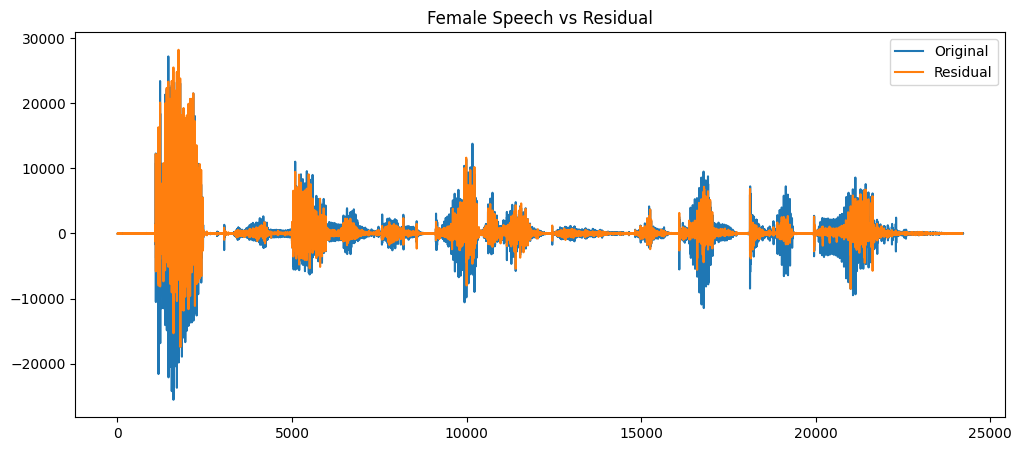

In [39]:
# Plot original vs. residual
plt.figure(figsize=(12, 5))
plt.plot(female_speech, label='Original')
plt.plot(female_residual, label='Residual')
plt.legend()
plt.title('Female Speech vs Residual')
plt.show()

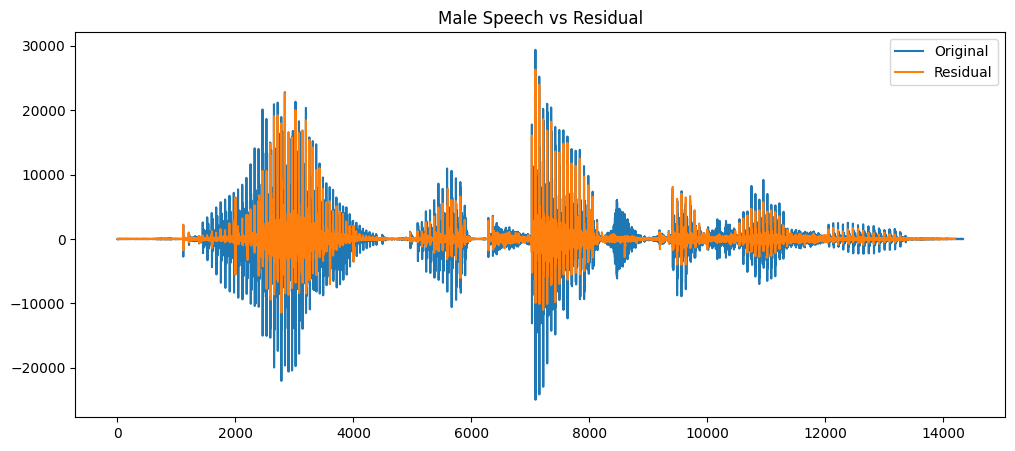

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(male_speech, label='Original')
plt.plot(male_residual, label='Residual')
plt.legend()
plt.title('Male Speech vs Residual')
plt.show()

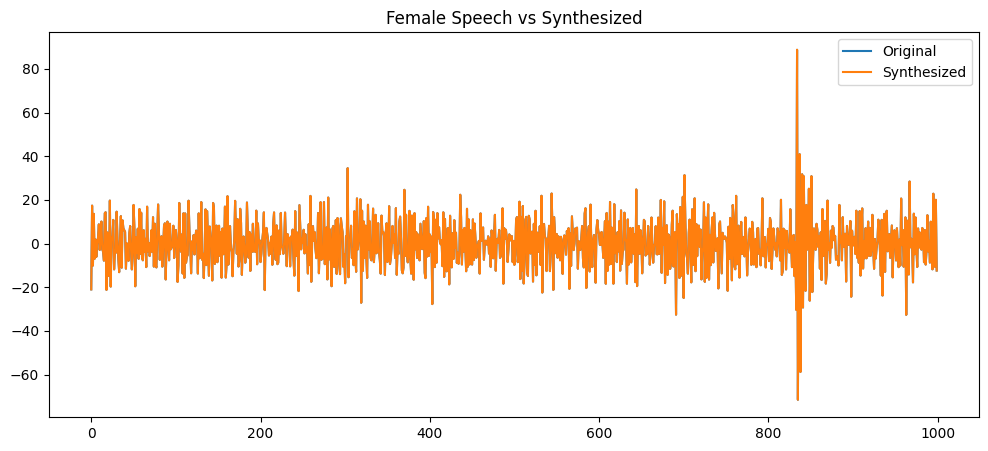

In [20]:
# Plot original vs. synthesized
plt.figure(figsize=(12, 5))
plt.plot(female_speech[:1000], label='Original')
plt.plot(female_synthesized[:1000], label='Synthesized')
plt.legend()
plt.title('Female Speech vs Synthesized')
plt.show()

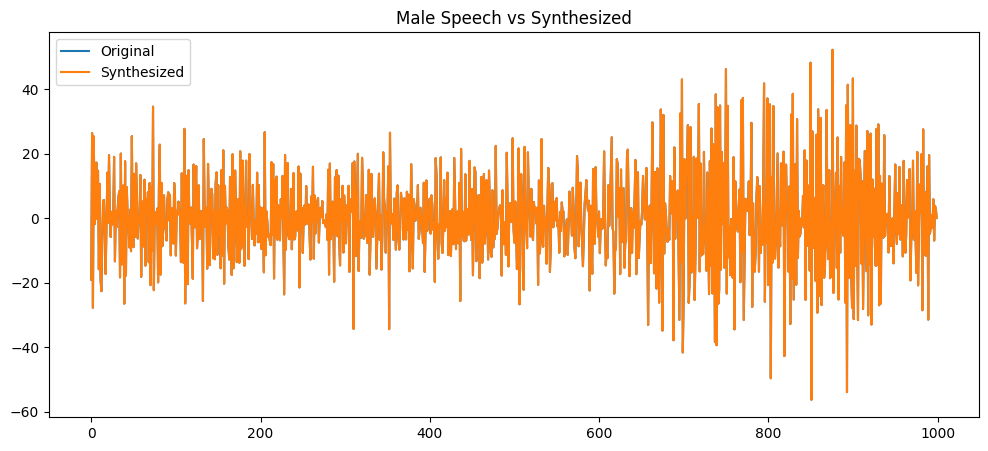

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(male_speech[:1000], label='Original')
plt.plot(male_synthesized[:1000], label='Synthesized')
plt.legend()
plt.title('Male Speech vs Synthesized')
plt.show()

# 3.3 Quantization of the LP filter

In [22]:
def quantize_coefficients(coeffs, bits):
    step_size = 2 / (2**bits)  # Uniform quantization step
    quantized_coeffs = np.round(coeffs / step_size) * step_size
    return quantized_coeffs

In [23]:
def compute_spectral_distortion(original_coeffs, quantized_coeffs, fft_size=FFT_SIZE):
    P_orig = np.abs(np.fft.fft(original_coeffs, fft_size))**2 + EPSILON
    P_quant = np.abs(np.fft.fft(quantized_coeffs, fft_size))**2 + EPSILON
    return np.sqrt(np.mean((10 * np.log10(P_orig) - 10 * np.log10(P_quant))**2))

In [24]:
bit_rates = [5, 4, 3]
female_sd = {}
male_sd = {}
for bits in bit_rates:
    female_quantized = [quantize_coefficients(lpc, bits) for lpc in female_lpc]
    male_quantized = [quantize_coefficients(lpc, bits) for lpc in male_lpc]
    
    female_sd[bits] = np.mean([compute_spectral_distortion(orig, quant) for orig, quant in zip(female_lpc, female_quantized)])
    male_sd[bits] = np.mean([compute_spectral_distortion(orig, quant) for orig, quant in zip(male_lpc, male_quantized)])

In [25]:
print("Spectral Distortion (SD) for Female Speech:", female_sd)
print("Spectral Distortion (SD) for Male Speech:", male_sd)

Spectral Distortion (SD) for Female Speech: {5: np.float64(0.7193460471162332), 4: np.float64(1.3927352944331386), 3: np.float64(2.6575811277318153)}
Spectral Distortion (SD) for Male Speech: {5: np.float64(0.9091773029501049), 4: np.float64(1.6862712778748803), 3: np.float64(2.8146754350505407)}


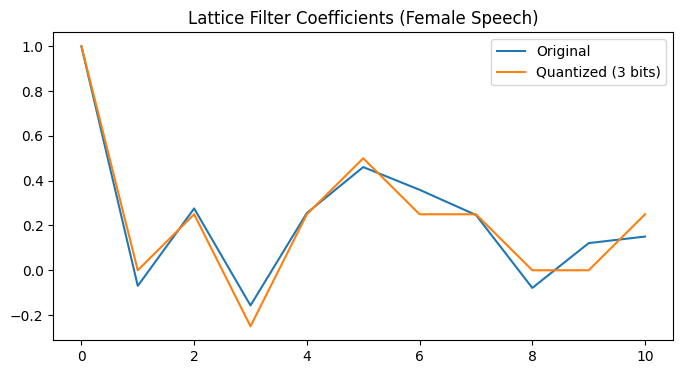

In [26]:
# Plot lattice filter coefficients
plt.figure(figsize=(8, 4))
plt.plot(female_lpc[10], label='Original')
plt.plot(quantize_coefficients(female_lpc[10], 3), label='Quantized (3 bits)')
plt.legend()
plt.title('Lattice Filter Coefficients (Female Speech)')
plt.show()

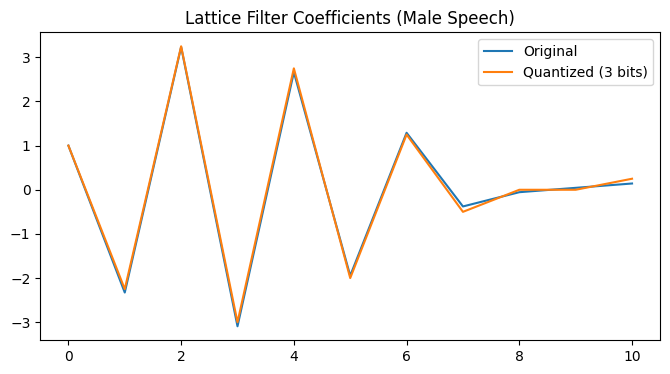

In [27]:
# Plot lattice filter coefficients
plt.figure(figsize=(8, 4))
plt.plot(male_lpc[10], label='Original')
plt.plot(quantize_coefficients(male_lpc[10], 3), label='Quantized (3 bits)')
plt.legend()
plt.title('Lattice Filter Coefficients (Male Speech)')
plt.show()

TO-DO: Add conclusion here